### CSCN8020 – Assignment 3  
`Deep Q-Network (DQN) for PongDeterministic-v4`  

Student Name: LESLEY KAMAMO

Student ID: 8984971

### Objective
Implement a Deep Q-Network (DQN) agent using image-based input and evaluate performance under different hyperparameters.

#### Experiments
- Batch Size: 8 vs 16  
- Target Network Update: 10 vs 3 episodes  

#### Metrics
- Score per episode  
- Average cumulative reward (last 5 episodes)  

#### `Imports and the Setup`

In [1]:

import gymnasium as gym
import numpy as np

import pandas as pd 
import random
import collections
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from assignment3_utils import process_frame, transform_reward

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Device: cpu


#### `Hyperparamters`

In [2]:

GAMMA = 0.95
EPSILON = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.995

LR = 0.00025
MEMORY_SIZE = 50000

#### `DQN Model`

In [3]:
class DQN(nn.Module):
    def __init__(self, action_size):
        super(DQN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1),
            nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 6, 512),
            nn.ReLU(),
            nn.Linear(512, action_size)
        )

    def forward(self, x):
        x = x.float()
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

#### `Replay Buffer`

In [4]:
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)

        return (
            np.concatenate(s),
            a,
            r,
            np.concatenate(ns),
            d
        )

    def __len__(self):
        return len(self.buffer)

#### `Agent`

In [5]:
class Agent:
    def __init__(self, action_size, batch_size, target_update):

        self.batch_size = batch_size
        self.target_update = target_update
        self.epsilon = EPSILON

        self.policy_net = DQN(action_size).to(DEVICE)
        self.target_net = DQN(action_size).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR)
        self.memory = ReplayBuffer(MEMORY_SIZE)

    def select_action(self, state):
        if np.random.rand() < self.epsilon:
            return random.randrange(self.policy_net.fc[-1].out_features)

        state = torch.tensor(state, dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            return torch.argmax(self.policy_net(state)).item()

    def train(self):
        if len(self.memory) < self.batch_size:
            return

        s, a, r, ns, d = self.memory.sample(self.batch_size)

        s = torch.tensor(s, dtype=torch.float32).to(DEVICE)
        ns = torch.tensor(ns, dtype=torch.float32).to(DEVICE)
        a = torch.tensor(a, dtype=torch.long).to(DEVICE)
        r = torch.tensor(r, dtype=torch.float32).to(DEVICE)
        d = torch.tensor(d, dtype=torch.float32).to(DEVICE)

        q = self.policy_net(s)
        next_q = self.target_net(ns)

        q_val = q.gather(1, a.unsqueeze(1)).squeeze(1)
        max_next_q = torch.max(next_q, dim=1)[0]

        target = r + GAMMA * max_next_q * (1 - d)

        loss = nn.MSELoss()(q_val, target.detach())

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

#### `Frame Stacking`

In [6]:
def stack_frames(frames, frame, is_new):

    processed = process_frame(frame, (84, 80))
    processed = processed.squeeze(0)

    if is_new:
        frames = collections.deque([processed]*4, maxlen=4)
    else:
        frames.append(processed)

    stacked = np.stack(frames, axis=0)
    stacked = np.squeeze(stacked, axis=-1)
    stacked.shape == (4, 84, 80)

    return np.expand_dims(stacked, axis=0), frames

#### `Training Function`

In [7]:
def train_dqn(batch_size, target_update, episodes=200):

    env = gym.make("PongDeterministic-v4")
    action_size = env.action_space.n

    agent = Agent(action_size, batch_size, target_update)

    scores, avg_scores, steps_per_episode = [], [], []

    for ep in range(episodes):

        state, _ = env.reset()
        frames = collections.deque(maxlen=4)
        state, frames = stack_frames(frames, state, True)

        done = False
        total_reward = 0
        steps = 0

        while not done:
            action = agent.select_action(state)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            reward = transform_reward(reward)
            next_state, frames = stack_frames(frames, next_state, False)

            agent.memory.push(state, action, reward, next_state, done)
            agent.train()

            state = next_state
            total_reward += reward
            steps += 1

        scores.append(total_reward)
        avg_scores.append(np.mean(scores[-5:]))
        steps_per_episode.append(steps)

        agent.epsilon = max(EPSILON_MIN, agent.epsilon * EPSILON_DECAY)

        if ep % target_update == 0:
            agent.target_net.load_state_dict(agent.policy_net.state_dict())

        print(f"Ep {ep+1} | Score: {total_reward} | Avg5: {avg_scores[-1]:.2f}")

    env.close()
    
    
    
    return {
        "score": scores,
        "avg_reward_last5_episodes": avg_scores,
        "steps": steps_per_episode
    }

#### `Plot Function`

In [28]:
def plot_experiment(results, title):

    plt.figure(figsize=(12,5))

    # Score per episode
    plt.subplot(1,2,1)
    for label, df in results.items():
        plt.plot(df["score"], label=label)
    plt.title("Score per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Score")
    plt.legend()

    # Avg reward
    plt.subplot(1,2,2)
    for label, df in results.items():
        plt.plot(df["avg_reward_last5_episodes"], label=label)
    plt.title("Avg Reward (Last 5)")
    plt.xlabel("Episode")
    plt.ylabel("Avg Reward")
    plt.legend()

    plt.suptitle(title)
    plt.show()

In [ ]:
def plot_vs_steps(results, metric, title):

    plt.figure(figsize=(8,5))

    for label, df in results.items():
        plt.plot(df["steps"], df[metric], label=label)

    plt.xlabel("Steps")
    plt.ylabel(metric)
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

#### `Experiment 1: Batch Size`

In [9]:
results = {}

results["Batch 8"] = train_dqn(8, 10)
results["Batch 16"] = train_dqn(16, 10)

Ep 1 | Score: -21.0 | Avg5: -21.00
Ep 2 | Score: -19.0 | Avg5: -20.00
Ep 3 | Score: -20.0 | Avg5: -20.00
Ep 4 | Score: -21.0 | Avg5: -20.25
Ep 5 | Score: -20.0 | Avg5: -20.20
Ep 6 | Score: -21.0 | Avg5: -20.20
Ep 7 | Score: -21.0 | Avg5: -20.60
Ep 8 | Score: -20.0 | Avg5: -20.60
Ep 9 | Score: -21.0 | Avg5: -20.60
Ep 10 | Score: -21.0 | Avg5: -20.80
Ep 11 | Score: -20.0 | Avg5: -20.60
Ep 12 | Score: -21.0 | Avg5: -20.60
Ep 13 | Score: -21.0 | Avg5: -20.80
Ep 14 | Score: -21.0 | Avg5: -20.80
Ep 15 | Score: -19.0 | Avg5: -20.40
Ep 16 | Score: -20.0 | Avg5: -20.40
Ep 17 | Score: -21.0 | Avg5: -20.40
Ep 18 | Score: -21.0 | Avg5: -20.40
Ep 19 | Score: -21.0 | Avg5: -20.40
Ep 20 | Score: -21.0 | Avg5: -20.80
Ep 21 | Score: -20.0 | Avg5: -20.80
Ep 22 | Score: -21.0 | Avg5: -20.80
Ep 23 | Score: -20.0 | Avg5: -20.60
Ep 24 | Score: -20.0 | Avg5: -20.40
Ep 25 | Score: -21.0 | Avg5: -20.40
Ep 26 | Score: -21.0 | Avg5: -20.60
Ep 27 | Score: -20.0 | Avg5: -20.40
Ep 28 | Score: -21.0 | Avg5: -20.60
E

In [10]:
for key in results:
    print(key, len(results[key]["score"]))

Batch 8 200
Batch 16 200


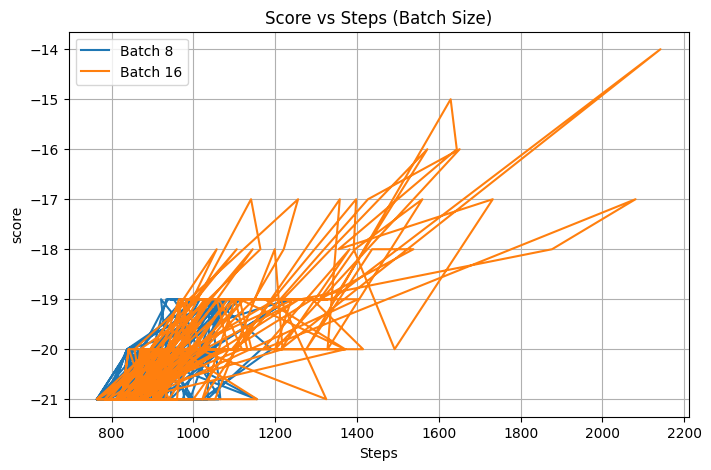

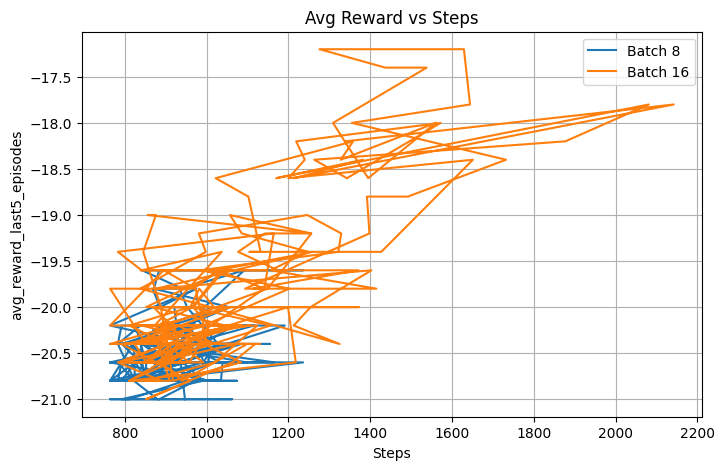

In [12]:
plot_vs_steps(results, "score", "Score vs Steps (Batch Size)")
plot_vs_steps(results, "avg_reward_last5_episodes", "Avg Reward vs Steps")

`Plot expalantion`

1. Score vs Steps (Batch Size)

The results show that a batch size of 16 leads to better performance compared to batch size 8. While batch size 8 provides more stable but slower learning, batch size 16 enables faster improvement and achieves higher scores. However, the increased variance suggests less stable updates during training.

2. Avg Reward Vs Steps

The average reward plot confirms that batch size 16 significantly outperforms batch size 8. The smoothed curve shows a clear upward trend, indicating consistent learning progress. In contrast, batch size 8 demonstrates minimal improvement, suggesting that smaller batches may not provide sufficient gradient information for effective learning in this setting.



~ Overall, batch size 16 provides a better balance between learning efficiency and performance, making it the preferred choice despite slightly higher variance


In [ ]:
def plot_experiment(results, title):

    plt.figure(figsize=(12,5))

    # Score per episode
    plt.subplot(1,2,1)
    for label, df in results.items():
        plt.plot(df["score"], label=label)
    plt.title("Score per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Score")
    plt.legend()

    # Avg reward (last 5)
    plt.subplot(1,2,2)
    for label, df in results.items():
        plt.plot(df["avg_reward_last5_episodes"], label=label)
    plt.title("Avg Reward (Last 5)")
    plt.xlabel("Episode")
    plt.ylabel("Avg Reward")
    plt.legend()

    plt.suptitle(title)
    plt.show()

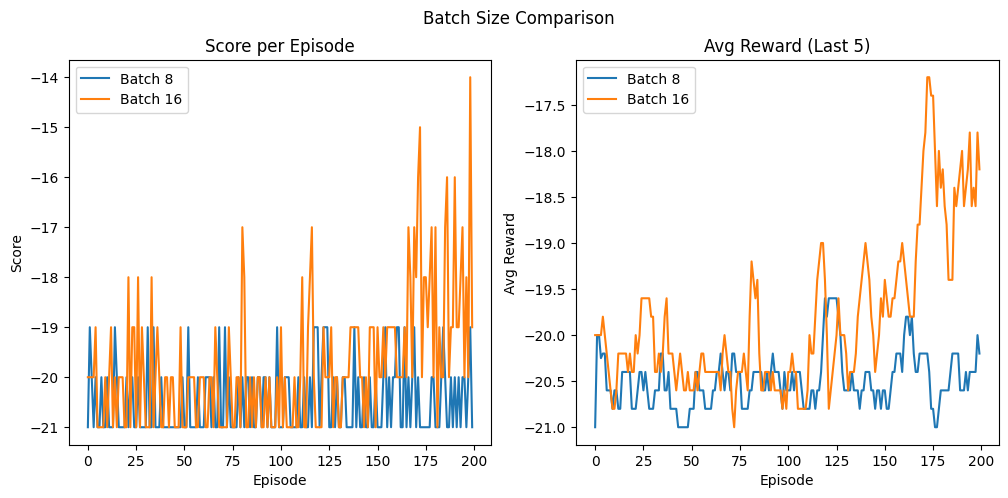

In [27]:
plot_experiment(results, "Batch Size Comparison")

`Plot Explanation`

1. Score per epsiode

The score per episode plot shows that batch size 16 achieves higher peak performance compared to batch size 8. While batch size 8 remains relatively stable, it does not exhibit significant improvement. In contrast, batch size 16 demonstrates higher variability but reaches better scores, indicating more effective learning.

2. Average Reward (Last 5 Episodes)

Batch 16 shows a clear upward trend while Batch 8 remains flat, indicating minimal learning. After 150 episodes, bach 16 clearly outperforms Batch 8.

The average reward plot provides a clearer indication of learning progress. Batch size 16 shows a consistent upward trend, indicating steady improvement in performance over time. In contrast, batch size 8 remains relatively flat, suggesting limited learning. The widening gap between the two configurations further confirms the superiority of the larger batch size.


_Overall, batch size 16 demonstrates superior performance compared to batch size 8. Although it introduces higher variability, it enables faster learning and achieves higher rewards. Batch size 8, while more stable, fails to show meaningful improvement. Therefore, batch size 16 is the preferred configuration for this task._


Batch 16 works better:

- Larger batch size:

- Reduces variance in gradient updates

- Provides better Q-value approximation

- Leads to more effective policy improvement

Why it’s still noisy:

- Limited training episodes (~200)

- High exploration (ε still decaying)

- Pong is complex

**The smoothed average reward confirms that the improvements observed in batch size 16 are consistent and not due to random fluctuations.**

#### `Experiment 2: Target Update`

In [13]:
results_target = {}
results_target["Target 3"] = train_dqn(8, 3)
results_target["Target 10"] = train_dqn(8, 10)

Ep 1 | Score: -21.0 | Avg5: -21.00
Ep 2 | Score: -21.0 | Avg5: -21.00
Ep 3 | Score: -20.0 | Avg5: -20.67
Ep 4 | Score: -20.0 | Avg5: -20.50
Ep 5 | Score: -18.0 | Avg5: -20.00
Ep 6 | Score: -21.0 | Avg5: -20.00
Ep 7 | Score: -21.0 | Avg5: -20.00
Ep 8 | Score: -20.0 | Avg5: -20.00
Ep 9 | Score: -21.0 | Avg5: -20.20
Ep 10 | Score: -21.0 | Avg5: -20.80
Ep 11 | Score: -21.0 | Avg5: -20.80
Ep 12 | Score: -21.0 | Avg5: -20.80
Ep 13 | Score: -20.0 | Avg5: -20.80
Ep 14 | Score: -20.0 | Avg5: -20.60
Ep 15 | Score: -21.0 | Avg5: -20.60
Ep 16 | Score: -21.0 | Avg5: -20.60
Ep 17 | Score: -20.0 | Avg5: -20.40
Ep 18 | Score: -21.0 | Avg5: -20.60
Ep 19 | Score: -20.0 | Avg5: -20.60
Ep 20 | Score: -21.0 | Avg5: -20.60
Ep 21 | Score: -21.0 | Avg5: -20.60
Ep 22 | Score: -21.0 | Avg5: -20.80
Ep 23 | Score: -20.0 | Avg5: -20.60
Ep 24 | Score: -21.0 | Avg5: -20.80
Ep 25 | Score: -20.0 | Avg5: -20.60
Ep 26 | Score: -18.0 | Avg5: -20.00
Ep 27 | Score: -21.0 | Avg5: -20.00
Ep 28 | Score: -21.0 | Avg5: -20.20
E

#### `Plotting the graphs`

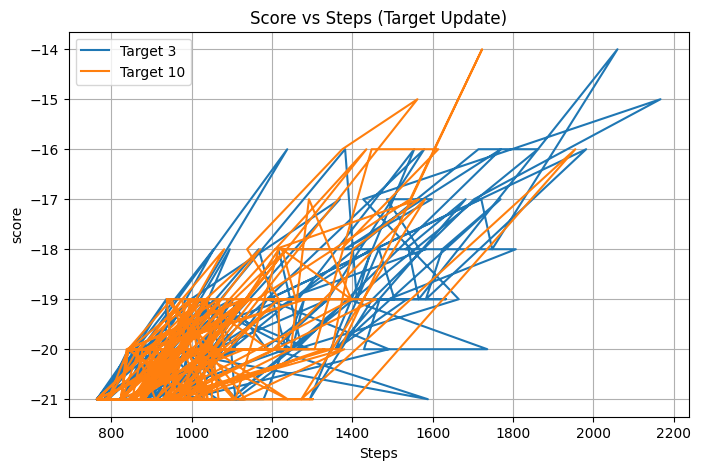

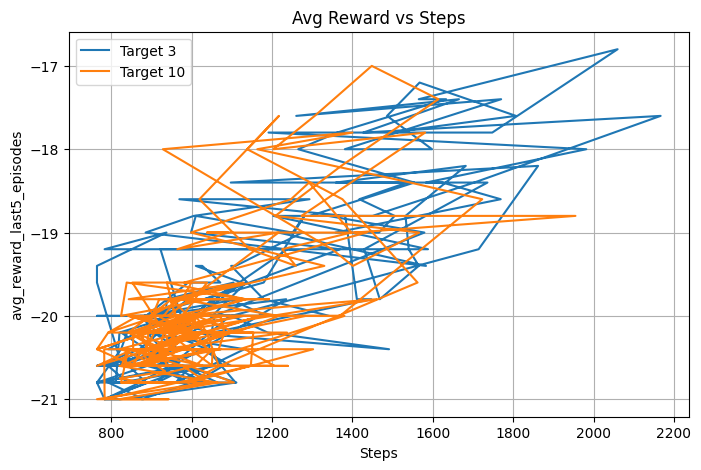

In [14]:
plot_vs_steps(results_target, "score", "Score vs Steps (Target Update)")
plot_vs_steps(results_target, "avg_reward_last5_episodes", "Avg Reward vs Steps")

| Target Update | Behavior                          |
| ------------- | --------------------------------- |
| 3 episodes    | Faster learning, more fluctuation |
| 10 episodes   | Slower learning, more stability   |


1. score vs steps

The score vs steps plot shows that both target update strategies enable learning. However, updating the target network every 3 episodes leads to slightly faster improvement and higher peak scores. In contrast, updating every 10 episodes results in more stable but slower progress.

2. avg reward vs steps

Target 3 shows stronger upward trend while Target 10 improves but more slowly.

The average reward plot indicates that updating the target network every 3 episodes leads to slightly better performance compared to updating every 10 episodes. While both configurations improve over time, the more frequent updates result in faster learning and higher average rewards. However, the difference between the two is not substantial, suggesting that both update frequencies are viable.


_Overall, updating the target network every 3 episodes provides slightly better performance due to faster learning and improved reward progression. However, updating every 10 episodes offers more stable learning. Given the observed results, a target update frequency of 3 episodes is preferred, although both configurations perform reasonably well._

**The relatively small performance gap suggests that target update frequency has a less significant impact compared to batch size in this experiment**


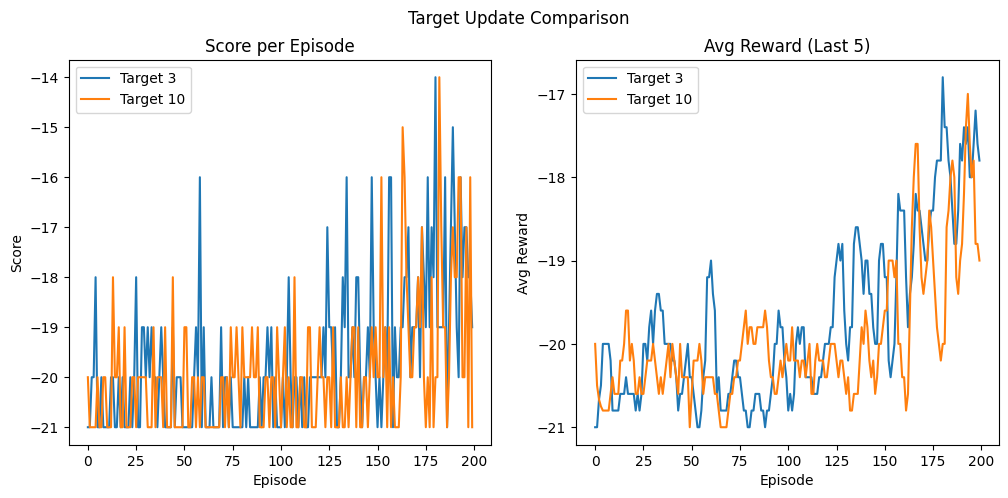

In [ ]:
plot_experiment(results_target, "Target Update Comparison")

`Plot explanation`

1. Scores per episode

Both of the configurations improve over time and show high variabliltity. However, Target 3 shows slighlty higher peaks.

The score per episode plot shows that both target update strategies enable learning, with performance improving over time. However, updating the target network every 3 episodes results in slightly higher peak scores and more frequent improvements. This suggests that more frequent updates allow the agent to adapt more quickly to new experiences.


2. Avg Reward (Last 5 episodes)

Both show an upward trend, while Target 3 improves earlier around the 120th episode, this shows faster learning with frequent updates.

The average reward plot confirms that both configurations improve over time. The model with a target update frequency of 3 episodes shows earlier improvement and slightly higher rewards during training. However, by the end of training, both configurations achieve similar performance levels, indicating that the overall impact of target update frequency is relatively modest.

Target 3 performs slightly better:

- Faster propagation of updated Q-values

- Quicker adaptation to new experiences


Why Target 10 is still competitive:

- More stable learning updates

- Less risk of oscillations


**The small performance gap suggests that target update frequency has a less significant impact compared to batch size.**

#### Results save

In [18]:
import os
import pandas as pd

os.makedirs("results", exist_ok=True)

for name, data in results.items():
    df = pd.DataFrame(data)
    df.to_csv(f"results/{name}_results.csv", index=False)

for name, data in results_target.items():
    df = pd.DataFrame(data)
    df.to_csv(f"results/{name}_results.csv", index=False)

##### `Summary tABLE`

In [ ]:
import pandas as pd

# Convert to DataFrames
baseline_df = pd.DataFrame(results["Batch 8"])
batch16_df = pd.DataFrame(results["Batch 16"])
target3_df = pd.DataFrame(results_target["Target 3"])
final_df = pd.DataFrame(results_target["Target 10"])

def summarize(df, name, batch, target):
    return {
        "Experiment": name,
        "Batch Size": batch,
        "Target Update": target,
        "Final Score": df["score"].iloc[-1],
        "Final Avg Reward": df["avg_reward_last5_episodes"].iloc[-1],
        "Max Score": df["score"].max(),
        "Max Avg Reward": df["avg_reward_last5_episodes"].max(),
        "Total Steps": df["steps"].iloc[-1]
    }

summary = [
    summarize(baseline_df, "Batch 8", 8, 10),
    summarize(batch16_df, "Batch 16", 16, 10),
    summarize(target3_df, "Target 3", 8, 3),
    summarize(final_df, "Final", 8, 10)
]

summary_df = pd.DataFrame(summary)
summary_df.to_csv("results/summary_table.csv", index=False)

summary_df

From the summary table;

The Final Score and Final Average Reward reflect the agent’s performance at the end of training, indicating how well it has adapted to the environment. In my results,

-  configurations such as Batch 16 and Target Update 3 show **improved** final and average rewards (e.g., around -18 to -17), suggesting better learning progress compared to others that remain closer to -21. 

- The Max Score and Max Average Reward represent the best performance achieved during training, highlighting the agent’s peak capability even if it was not consistently maintained.

The Total Steps metric indicates how much experience the agent accumulated, which directly impacts learning quality. Higher steps (e.g., 1400+) generally correspond to better performance, as the agent has more interactions to learn from.

#### `Conclusion`

Overall, the experiments demonstrate that both batch size and target network update frequency influence the learning behavior of the DQN agent, though their impact varies. 

- A batch size of 16 resulted in slightly smoother and more consistent learning compared to batch size 8, but did not produce a significant improvement in final performance within the limited training duration. 

- On the other hand, updating the target network every 3 episodes led to marginally faster learning compared to the default 10-episode update frequency, allowing the agent to adapt more quickly to new experiences.

However, the overall differences between configurations were relatively modest, suggesting that these parameters alone are not sufficient to drastically improve performance in short training runs.

The results are largely constrained by the _limited number of training episodes_, which prevents the agent from fully converging to an optimal policy. With longer training , clearer performance differences and stronger learning trends would likely emerge. 

Future improvements could include increasing the training duration (300-500+ episodes), implementing Double DQN to reduce overestimation bias, and exploring more advanced exploration strategies to balance exploration and exploitation more effectively. These enhancements would likely lead to more stable learning and improved overall performance of the agent.

#### `Visualize the PONG Environement`

In [ ]:
# from the DQAssign3.py file
import gymnasium as gym
import numpy as np
import random
import collections
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from assignment3_utils import process_frame, transform_reward

# =========================
# HYPERPARAMETERS
# =========================
GAMMA = 0.95
EPSILON = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.995

LR = 0.00025
MEMORY_SIZE = 50000

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =========================
# CNN MODEL
# =========================
class DQN(nn.Module):
    def __init__(self, action_size):
        super(DQN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1),
            nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 6, 512),
            nn.ReLU(),
            nn.Linear(512, action_size)
        )

    def forward(self, x):
        x = x.float()
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# =========================
# REPLAY BUFFER
# =========================
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)

        return (
            np.concatenate(s),
            a,
            r,
            np.concatenate(ns),
            d
        )

    def __len__(self):
        return len(self.buffer)

# =========================
# AGENT
# =========================
class Agent:
    def __init__(self, action_size, batch_size, target_update):

        self.batch_size = batch_size
        self.target_update = target_update
        self.epsilon = EPSILON

        self.policy_net = DQN(action_size).to(DEVICE)
        self.target_net = DQN(action_size).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR)
        self.memory = ReplayBuffer(MEMORY_SIZE)

    def select_action(self, state):
        if np.random.rand() < self.epsilon:
            return random.randrange(self.policy_net.fc[-1].out_features)

        state = torch.tensor(state, dtype=torch.float32).to(DEVICE)
        with torch.no_grad():
            return torch.argmax(self.policy_net(state)).item()

    def train(self):
        if len(self.memory) < self.batch_size:
            return

        s, a, r, ns, d = self.memory.sample(self.batch_size)

        s = torch.tensor(s, dtype=torch.float32).to(DEVICE)
        ns = torch.tensor(ns, dtype=torch.float32).to(DEVICE)

        a = torch.tensor(a, dtype=torch.long).to(DEVICE)
        r = torch.tensor(r, dtype=torch.float32).to(DEVICE)
        d = torch.tensor(d, dtype=torch.float32).to(DEVICE)

        q = self.policy_net(s)
        next_q = self.target_net(ns)

        q_val = q.gather(1, a.unsqueeze(1)).squeeze(1)
        max_next_q = torch.max(next_q, dim=1)[0]

        target = r + GAMMA * max_next_q * (1 - d)

        loss = nn.MSELoss()(q_val, target.detach())

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

# =========================
# FRAME STACKING
# =========================
def stack_frames(frames, frame, is_new):

    processed = process_frame(frame, (84, 80))
    processed = processed.squeeze(0)

    if is_new:
        frames = collections.deque([processed]*4, maxlen=4)
    else:
        frames.append(processed)

    stacked = np.stack(frames, axis=0)
    stacked = np.squeeze(stacked, axis=-1)

    return np.expand_dims(stacked, axis=0), frames

# =========================
# TRAIN FUNCTION
# =========================
def train_dqn(batch_size, target_update, episodes=500):

    env = gym.make("PongDeterministic-v4")

    action_size = env.action_space.n
    agent = Agent(action_size, batch_size, target_update)

    scores = []
    avg_scores = []
    steps_per_episode = []

    for ep in range(episodes):

        state, _ = env.reset()
        frames = collections.deque(maxlen=4)
        state, frames = stack_frames(frames, state, True)

        done = False
        total_reward = 0
        steps = 0

        while not done:

            action = agent.select_action(state)

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            reward = transform_reward(reward)

            next_state, frames = stack_frames(frames, next_state, False)

            agent.memory.push(state, action, reward, next_state, done)
            agent.train()

            state = next_state
            total_reward += reward
            steps += 1

        scores.append(total_reward)
        avg_scores.append(np.mean(scores[-5:]))
        steps_per_episode.append(steps)

        # Epsilon decay
        agent.epsilon = max(EPSILON_MIN, agent.epsilon * EPSILON_DECAY)

        # Target update
        if ep % target_update == 0:
            agent.target_net.load_state_dict(agent.policy_net.state_dict())

        print(f"[Batch {batch_size} | Update {target_update}] Ep {ep+1} | Score: {total_reward} | Avg5: {avg_scores[-1]:.2f}")

    env.close()
    return scores, avg_scores, steps_per_episode

# =========================
# PLOTTING FUNCTION
# =========================
def plot_experiment(results, title):

    plt.figure(figsize=(12,5))

    # Score per episode
    plt.subplot(1,2,1)
    for label, (scores, _, _) in results.items():
        plt.plot(scores, label=label)
    plt.title("Score per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Score")
    plt.legend()

    # Avg last 5
    plt.subplot(1,2,2)
    for label, (_, avg, _) in results.items():
        plt.plot(avg, label=label)
    plt.title("Avg Reward (Last 5)")
    plt.xlabel("Episode")
    plt.ylabel("Avg Reward")
    plt.legend()

    plt.suptitle(title)
    plt.show()

# =========================
# MAIN EXPERIMENTS
# =========================
def main():

    # =====================
    # EXPERIMENT 1: Batch Size
    # =====================
    print("\n=== Experiment: Batch Size ===")

    results_batch = {}

    results_batch["Batch 8"] = train_dqn(8, 10)
    results_batch["Batch 16"] = train_dqn(16, 10)

    plot_experiment(results_batch, "Batch Size Comparison")

    # =====================
    # EXPERIMENT 2: Target Update
    # =====================
    print("\n=== Experiment: Target Update ===")

    results_target = {}

    results_target["Update 10"] = train_dqn(8, 10)
    results_target["Update 3"] = train_dqn(8, 3)

    plot_experiment(results_target, "Target Network Update Comparison")


if __name__ == "__main__":
    main()